Reto: "Predicción de Fallos en Equipos en Plantas Energéticas a 15 días vista"
Objetivo del Reto:
Evolucionar la solución para desarrollar un modelo analítico predictivo que permita anticipar fallos a 15 días vista en los equipos de la planta energética con una precisión mínima del 80% (accuracy ≥ 0.80) y por lo menos un 0.75 de f1.

Por un lado se quiere predecir las horas operativas que tendrá un equipo en los próximos 15 días, de cara a considerar su mantenimiento conforme a las horas recomendadas de revisión.
Por otro lado, se quiere evaluar si una máquina fallará en los próximos 15 días, con un 80% de fiabilidad.
Evalúa la robustés del modelo en el tiempo.

Para lograr esto, deberéis:

Mezclar y preprocesar los datos de los 3 datasets proporcionados, teniendo en cuenta la componente temporal.
Seleccionar variables relevantes y generar nuevas características si es necesario. Considera usar PCA para reducir dimensiones (conservando 95% de la varianza).
Construir y evaluar múltiples modelos predictivos, que inclyan forecasting y comparando su rendimiento.
Ajustar hiperparámetros y optimizar el modelo para alcanzar la precisión deseada.
Documentar los hallazgos y justificar la elección del mejor modelo.
Bonus 1: Encontrar patrones de fallos
Usa K-Means o DBSCAN para agrupar los equipos según sus condiciones operativas y comportamiento previo a los fallos.
Incluye las siguientes características para el clustering:
Promedio de temperatura y vibración por equipo.
Desviación estándar de temperatura y vibración.
Horas operativas acumuladas promedio.
Visualiza los clusters utilizando gráficos de dispersión o mapas de calor.
Interpreta los resultados: ¿Qué patrones emergen? ¿Hay grupos de equipos más propensos a fallar?


#### *Se cargan los tres datasets y se muestran las primeras filas*

In [29]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import io
import sys
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score


In [2]:
# Cargar los tres datasets
caracteristicas_df = pd.read_csv("../src/Caracteristicas_Equipos.csv")
ordenes_df = pd.read_csv("../src/Historicos_Ordenes.csv")
condiciones_df = pd.read_csv("../src/Registros_Condiciones.csv")

# Mostrar las primeras filas de cada dataset para revisar su estructura
# Mostrar características
display(Markdown("### 🛠️ Características de Equipos"))
display(caracteristicas_df.head())

# Mostrar órdenes históricas
display(Markdown("### 📋 Históricos de Órdenes"))
display(ordenes_df.head())

# Mostrar condiciones operativas
display(Markdown("### 📊 Registros de Condiciones"))
display(condiciones_df.head())


### 🛠️ Características de Equipos

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Bomba,Fabricante_A,Modelo_8,432,657
1,2,Generador,Fabricante_B,Modelo_2,393,522
2,3,Motor,Fabricante_C,Modelo_7,398,885
3,4,Bomba,Fabricante_D,Modelo_4,121,668
4,5,Generador,Fabricante_C,Modelo_7,51,958


### 📋 Históricos de Órdenes

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B


### 📊 Registros de Condiciones

,ID_Registro,ID_Equipo,Fecha,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,1,2021-01-01,36.587104,4.430381,579
1,2,106,2021-01-01,53.268051,0.534711,577
2,3,446,2021-01-01,47.176472,7.116958,263
3,4,107,2021-01-01,76.404597,2.696906,491
4,5,108,2021-01-01,50.729327,6.996772,589


In [3]:
def print_info(df, titulo):
    buffer = io.StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    display(Markdown(f"### {titulo}"))
    display(Markdown(f"```\n{info_str}\n```"))

# Mostrar info de cada DataFrame
print_info(caracteristicas_df, "🛠️ Info: Características de Equipos")
print_info(ordenes_df, "📋 Info: Históricos de Órdenes")
print_info(condiciones_df, "📊 Info: Registros de Condiciones")


### 🛠️ Info: Características de Equipos

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID_Equipo                    500 non-null    int64 
 1   Tipo_Equipo                  500 non-null    object
 2   Fabricante                   500 non-null    object
 3   Modelo                       500 non-null    object
 4   Potencia_kW                  500 non-null    int64 
 5   Horas_Recomendadas_Revision  500 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 23.6+ KB

```

### 📋 Info: Históricos de Órdenes

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31866 entries, 0 to 31865
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Orden             31866 non-null  int64 
 1   ID_Equipo            31866 non-null  int64 
 2   Fecha                31866 non-null  object
 3   Tipo_Mantenimiento   31866 non-null  object
 4   Costo_Mantenimiento  31866 non-null  int64 
 5   Duracion_Horas       31866 non-null  int64 
 6   Ubicacion            31866 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.7+ MB

```

### 📊 Info: Registros de Condiciones

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730500 entries, 0 to 730499
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID_Registro       730500 non-null  int64  
 1   ID_Equipo         730500 non-null  int64  
 2   Fecha             730500 non-null  object 
 3   Temperatura_C     730500 non-null  float64
 4   Vibracion_mm_s    730500 non-null  float64
 5   Horas_Operativas  730500 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 33.4+ MB

```

#### *Merge de los tres dataframes con las variables que suponemos más importantes*

In [4]:
def mezclar_datasets(caracteristicas_equipos, historicos_ordenes, registros_condiciones):
    """
    Une en un solo DataFrame la información de características, órdenes de mantenimiento
    y registros de condiciones operativas, usando un merge por ID_Equipo y Fecha.

    Rellena valores faltantes hacia adelante y ordena por ID_Equipo y Fecha.
    """
    merged_data = pd.merge(caracteristicas_equipos, historicos_ordenes, on='ID_Equipo', how='outer')
    merged_data = pd.merge(merged_data, registros_condiciones, on=['ID_Equipo', 'Fecha'], how='outer')
    merged_data = merged_data.sort_values(by=['ID_Equipo', 'Fecha'])
    merged_data = merged_data.fillna(method='ffill')

    return merged_data


In [7]:
df_mezclado = mezclar_datasets(caracteristicas_df, ordenes_df, condiciones_df)
display(df_mezclado.head(1000))

/tmp/ipykernel_55030/4234481521.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data = merged_data.fillna(method='ffill')


,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,ID_Orden,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,ID_Registro,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,NaN,NaN,NaN,NaN,NaN,NaN,2021-01-01,NaN,NaN,NaN,NaN,1,36.587104,4.430381,579
1,1,NaN,NaN,NaN,NaN,NaN,NaN,2021-01-02,NaN,NaN,NaN,NaN,740,24.495730,3.871645,592
2,1,NaN,NaN,NaN,NaN,NaN,NaN,2021-01-03,NaN,NaN,NaN,NaN,1101,54.798241,6.397340,611
3,1,NaN,NaN,NaN,NaN,NaN,NaN,2021-01-04,NaN,NaN,NaN,NaN,1762,82.709427,7.051379,622
4,1,NaN,NaN,NaN,NaN,NaN,NaN,2021-01-05,NaN,NaN,NaN,NaN,2344,75.120966,0.861798,624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,Bomba,Fabricante_A,Modelo_8,432.0,657.0,21552.0,2023-09-23,Preventivo,793.0,1.0,Ubicacion_A,497885,23.869112,9.093701,712
996,1,Bomba,Fabricante_A,Modelo_8,432.0,657.0,21552.0,2023-09-24,Preventivo,793.0,1.0,Ubicacion_A,498383,67.970881,9.637567,721
997,1,Bomba,Fabricante_A,Modelo_8,432.0,657.0,21552.0,2023-09-25,Preventivo,793.0,1.0,Ubicacion_A,498851,71.285251,3.148753,744
998,1,Bomba,Fabricante_A,Modelo_8,432.0,657.0,21552.0,2023-09-26,Preventivo,793.0,1.0,Ubicacion_A,499053,32.188319,3.761094,754


#### *Dataframe montado, eliminando nulos, y sustituyendo valores numéricos en columna categóricas, convertimos la columna Tipo_Mantenimiento en numérica siendo Correctivo=1 y Preventivo=0. También creamos columnas Día, Quincena, Mes y Año que son útiles para análisis estacionales o agrupaciones por periodos*

In [12]:
def preprocesamiento(df):
    """
    Limpia y transforma el DataFrame:
    - Elimina nulos y duplicados
    - Extrae día, quincena, mes y año desde la columna Fecha
    - Calcula Horas_Hasta_Revision
    - Convierte variables de tipo object a categóricas numéricas
    """
    # Eliminar nulos
    df = df.dropna()

    # Eliminar duplicados
    df = df.drop_duplicates()

    # Asegurarse de que 'Fecha' es tipo datetime
    df['Fecha'] = pd.to_datetime(df['Fecha'])

    # Añadir columnas temporales
    df['Dia'] = df['Fecha'].dt.day
    df['Quincena'] = df['Fecha'].dt.day.apply(lambda x: (x - 1) // 15 + 1)
    df['Mes'] = df['Fecha'].dt.month
    df['Año'] = df['Fecha'].dt.year

    # Añadir columna de horas hasta revisión
    df['horas_hasta_correctivo'] = df['Horas_Recomendadas_Revision'] - df['Horas_Operativas']

    # Convertir columnas object a códigos numéricos
    for column in df.select_dtypes(include=['object']).columns:
        df[column] = df[column].astype('category').cat.codes

    return df


In [13]:
df_limpio = preprocesamiento(df_mezclado)
display(df_limpio.head(500))

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,ID_Orden,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,...,Ubicacion,ID_Registro,Temperatura_C,Vibracion_mm_s,Horas_Operativas,Dia,Quincena,Mes,Año,horas_hasta_correctivo
29,1,0,0,8,432.0,657.0,391.0,2021-01-30,1,964.0,...,0,14588,84.711721,0.912324,895,30,2,1,2021,-238.0
30,1,0,0,8,432.0,657.0,391.0,2021-01-31,1,964.0,...,0,15270,87.295714,2.676511,901,31,3,1,2021,-244.0
31,1,0,0,8,432.0,657.0,391.0,2021-02-01,1,964.0,...,0,15514,86.196544,6.886018,918,1,1,2,2021,-261.0
32,1,0,0,8,432.0,657.0,391.0,2021-02-02,1,964.0,...,0,16369,57.088007,7.776112,938,2,1,2,2021,-281.0
33,1,0,0,8,432.0,657.0,391.0,2021-02-03,1,964.0,...,0,16759,94.758073,4.335325,962,3,1,2,2021,-305.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524,1,0,0,8,432.0,657.0,10939.0,2022-06-09,1,149.0,...,0,262469,43.487936,5.182205,638,9,1,6,2022,19.0
525,1,0,0,8,432.0,657.0,10939.0,2022-06-10,1,149.0,...,0,262999,53.374420,0.548433,643,10,1,6,2022,14.0
526,1,0,0,8,432.0,657.0,10939.0,2022-06-11,1,149.0,...,0,263371,99.892595,1.719609,660,11,1,6,2022,-3.0
527,1,0,0,8,432.0,657.0,10939.0,2022-06-12,1,149.0,...,0,263762,87.217616,1.992736,662,12,1,6,2022,-5.0


#### *Comprobamos que no tenemos duplicados o nulos después de tantos cambios.*

In [14]:
# Valores nulos por columna
print("Valores nulos por columna:\n", df_limpio.isnull().sum())

# Filas duplicadas (completas)
duplicados = df_limpio.duplicated()
print(f"\nNúmero de filas duplicadas: {duplicados.sum()}")

Valores nulos por columna:
 ID_Equipo                      0
Tipo_Equipo                    0
Fabricante                     0
Modelo                         0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
ID_Orden                       0
Fecha                          0
Tipo_Mantenimiento             0
Costo_Mantenimiento            0
Duracion_Horas                 0
Ubicacion                      0
ID_Registro                    0
Temperatura_C                  0
Vibracion_mm_s                 0
Horas_Operativas               0
Dia                            0
Quincena                       0
Mes                            0
Año                            0
horas_hasta_correctivo         0
dtype: int64

Número de filas duplicadas: 0


### Explicación paso a paso:

1. **`groupby([...])`**:
   Agrupa el DataFrame `info_equipos` según:
   - `ID_Equipo`: cada máquina o equipo.
   - `Potencia_kW`, `Horas_Recomendadas_Revision`: atributos técnicos del equipo.
   - `Tipo_Mantenimiento`: si fue correctivo (1) o preventivo (0).
   - `Quincena`: primera o segunda mitad del mes.
   - `Etc.`

2. **`.agg({...})`**:
   Aplica funciones de agregación específicas a las columnas numéricas:
   - `'Costo_Mantenimiento': 'sum'` → suma el coste de mantenimientos en cada grupo.
   - `'Temperatura_C': 'max'` → toma la temperatura máxima de ese periodo.
   - `'Vibracion_mm_s': 'max'` → lo mismo para la vibración.
   - `'Horas_Operativas': 'mean'` → promedio de horas trabajadas en esa quincena.
   - `'horas_hasta_correctivo': 'mean'` → promedio del margen hasta revisión recomendada.

3. **`.reset_index()`**:
   Convierte los índices de agrupación de nuevo en columnas.

In [15]:
def agregar_info_quincenal(df):
    """
    Agrupa datos por equipo y quincena para generar un resumen agregado.
    Calcula sumas, máximos y promedios de variables clave.
    """
    agrupado = df.groupby([
        'ID_Equipo',
        'Tipo_Equipo',
        'Fabricante',
        'Modelo',
        'Potencia_kW',
        'Horas_Recomendadas_Revision',
        'Tipo_Mantenimiento',
        'Quincena'
    ]).agg({
        'Costo_Mantenimiento': 'sum',
        'Temperatura_C': 'max',
        'Vibracion_mm_s': 'max',
        'Horas_Operativas': 'mean',
        'horas_hasta_correctivo': 'mean'
    }).reset_index()

    return agrupado


In [18]:
Datos_agregados = agregar_info_quincenal(df_limpio)
display(Datos_agregados.head(500))

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Tipo_Mantenimiento,Quincena,Costo_Mantenimiento,Temperatura_C,Vibracion_mm_s,Horas_Operativas,horas_hasta_correctivo
0,1,0,0,8,432.0,657.0,0,1,94391.0,94.264232,9.862454,160.821429,496.178571
1,1,0,0,8,432.0,657.0,0,2,239363.0,97.823893,9.931615,77.141176,579.858824
2,1,0,0,8,432.0,657.0,0,3,10184.0,89.525381,6.229608,150.250000,506.750000
3,1,0,0,8,432.0,657.0,1,1,341679.0,99.998314,9.982758,1303.188791,-646.188791
4,1,0,0,8,432.0,657.0,1,2,309888.0,99.825028,9.976351,1414.309446,-757.309446
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,61,0,3,7,77.0,585.0,1,2,367227.0,99.967573,9.998491,961.088328,-376.088328
496,61,0,3,7,77.0,585.0,1,3,14992.0,95.069786,9.406595,913.400000,-328.400000
497,61,3,3,0,384.0,611.0,1,1,11190.0,93.736700,9.630366,284.133333,326.866667
498,61,3,3,0,384.0,611.0,1,2,5222.0,78.799707,7.150000,402.571429,208.428571


Paso 1: Calcular correlaciones: Vamos a usar `.corr()` de pandas, que calcula la correlación de Pearson entre columnas numéricas.

Paso 2: Extraer correlación con la variable objetivo

Paso 3: Visualizar con heatmap (matplotlib + seaborn)

In [19]:
def mostrar_correlaciones(Datos_agregados, objetivo='Tipo_Mantenimiento'):
    # Correlación entre variables numéricas
    corr_matrix = Datos_agregados.corr(numeric_only=True)

    # Extraemos correlaciones con respecto al objetivo
    correlaciones_objetivo = corr_matrix[[objetivo]].drop(index=objetivo).sort_values(by=objetivo, ascending=False)
    correlaciones_objetivo = correlaciones_objetivo.round(3)

    # Mostrar tabla ordenada
    display(correlaciones_objetivo)

    # Mapa de calor de todas las correlaciones
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Mapa de calor de correlaciones")
    plt.tight_layout()
    plt.show()


,Tipo_Mantenimiento
Horas_Operativas,0.725
Temperatura_C,0.087
Vibracion_mm_s,0.077
Tipo_Equipo,0.012
ID_Equipo,0.011
Potencia_kW,0.002
Fabricante,-0.008
Modelo,-0.009
Horas_Recomendadas_Revision,-0.016
Quincena,-0.050


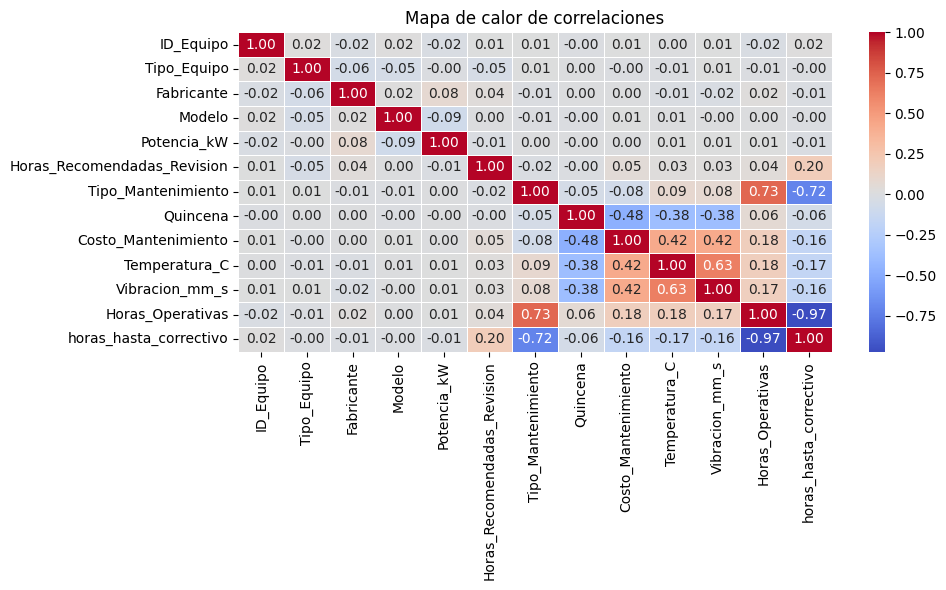

In [20]:
mostrar_correlaciones(Datos_agregados)

Recibe un DataFrame df (Datos_agregados).

Usa SelectKBest con ANOVA (f_classif) para seleccionar las mejores k características predictoras de Tipo_Mantenimiento.

Devuelve la lista de nombres de las mejores características.

In [22]:
def seleccionar_mejores_features(df, objetivo='Tipo_Mantenimiento', k=6):
    """
    Selecciona las k mejores características predictoras de la variable objetivo usando SelectKBest con ANOVA F-test.

    Parámetros:
    - df: DataFrame con todas las variables
    - objetivo: nombre de la variable objetivo (por defecto 'Tipo_Mantenimiento')
    - k: número de mejores características a seleccionar

    Devuelve:
    - Lista de nombres de las mejores características
    """
    # Separar variables predictoras y objetivo
    X = df.drop(objetivo, axis=1)
    y = df[objetivo]

    # Asegurar que solo pasamos columnas numéricas (SelectKBest no admite strings)
    X_numeric = X.select_dtypes(include='number')

    # Seleccionar mejores features
    selector = SelectKBest(score_func=f_classif, k=k)
    X_new = selector.fit_transform(X_numeric, y)

    # Extraer nombres
    best_features = X_numeric.columns[selector.get_support()]
    
    print("Mejores características seleccionadas:")
    print(best_features.tolist())
    
    return best_features.tolist()


In [23]:
mejores_features = seleccionar_mejores_features(Datos_agregados, k=6)

Mejores características seleccionadas:
['Quincena', 'Costo_Mantenimiento', 'Temperatura_C', 'Vibracion_mm_s', 'Horas_Operativas', 'horas_hasta_correctivo']


## *PCA*

In [25]:
def aplicar_pca(df, varianza_objetivo=0.95):
    """
    Aplica PCA a un DataFrame para reducir la dimensionalidad conservando la varianza especificada.

    - Estandariza los datos
    - Reduce dimensiones con PCA
    - Muestra varianza explicada y las cargas
    - Identifica la columna más importante para cada componente principal

    Retorna:
    - DataFrame con las componentes principales (pca_df)
    - DataFrame con las cargas por variable (loadings_df)
    - Series con la variable más importante por componente (important_features)
    """
    # Escalado de datos
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df.select_dtypes(include='number'))

    # PCA
    pca = PCA(n_components=varianza_objetivo)
    pca_data = pca.fit_transform(scaled_data)

    # DataFrame de componentes principales
    pca_df = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(pca_data.shape[1])])
    
    # Mostrar varianza explicada
    display(pd.DataFrame({
        'Componente': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
        'Varianza Explicada': pca.explained_variance_ratio_.round(4)
    }))

    # Cargas de los componentes
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    loadings_df = pd.DataFrame(
        loadings,
        index=df.select_dtypes(include='number').columns,
        columns=[f'PC{i+1}' for i in range(pca_data.shape[1])]
    )
    
    display(loadings_df)

    # Variables más importantes por componente
    important_features = loadings_df.abs().idxmax()
    display(important_features)

    return pca_df, loadings_df, important_features


In [26]:
pca_df, loadings_df, important_features = aplicar_pca(Datos_agregados)

,Componente,Varianza Explicada
0,PC1,0.2191
1,PC2,0.1669
2,PC3,0.0867
3,PC4,0.0854
4,PC5,0.0779
5,PC6,0.0758
6,PC7,0.0710
7,PC8,0.0668
8,PC9,0.0559
9,PC10,0.0496


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
ID_Equipo,-0.006649,-0.028229,-0.256811,0.137868,0.611429,0.680230,-0.266874,-0.077811,0.001207,0.020525
Tipo_Equipo,0.004784,0.007219,-0.458784,-0.451748,0.228898,0.041230,0.725899,0.065897,-0.005185,0.009390
Fabricante,0.004951,0.021501,0.671219,0.052204,-0.063737,0.385710,0.418462,-0.462261,0.062367,-0.029324
Modelo,0.002539,-0.010071,-0.094347,0.674916,-0.301182,0.311350,0.323582,0.492625,-0.019308,-0.016828
Potencia_kW,0.019898,0.004555,0.512554,-0.538490,0.060453,0.249521,-0.102969,0.606510,-0.052414,-0.001074
Horas_Recomendadas_Revision,-0.050029,-0.121610,0.350881,0.362892,0.680285,-0.452647,0.182530,0.156736,-0.033931,-0.013457
Tipo_Mantenimiento,0.708787,0.476427,-0.014095,0.027428,0.088300,-0.031315,-0.005420,0.004978,-0.104174,-0.393255
Quincena,-0.298213,0.667689,0.022932,0.031447,0.065810,-0.039450,0.004214,0.066609,0.498801,0.420087
Costo_Mantenimiento,0.448516,-0.608369,0.023699,0.016946,-0.012210,0.003675,0.022699,-0.042594,-0.360762,0.508554
Temperatura_C,0.536192,-0.594836,-0.000455,-0.011402,-0.010025,-0.005424,-0.015296,0.037864,0.405639,-0.079109


PC1                Horas_Operativas
PC2                        Quincena
PC3                      Fabricante
PC4                          Modelo
PC5     Horas_Recomendadas_Revision
PC6                       ID_Equipo
PC7                     Tipo_Equipo
PC8                     Potencia_kW
PC9                        Quincena
PC10            Costo_Mantenimiento
dtype: object

### 📊 1. **Varianza explicada**

| Componente | Varianza Explicada |
|------------|--------------------|
| PC1        | 21.91%             |
| PC2        | 16.69%             |
| PC3        | 8.67%              |
| PC4        | 8.54%              |
| PC5        | 7.79%              |
| PC6        | 7.58%              |
| PC7        | 7.10%              |
| PC8        | 6.68%              |
| PC9        | 5.59%              |
| PC10       | 4.96%              |

✅ **Interpretación**:
- Las dos primeras componentes (`PC1` + `PC2`) explican cerca del **38.6%** de la varianza total.
- Con 10 componentes, se explica el **100%** de la varianza de los datos estandarizados, porque tu parámetro de PCA fue `n_components=0.95`, así que estas 10 componentes eran las necesarias para cubrir al menos el 95%.

---

### 📌 2. **Cargas de los componentes principales**

Las *cargas* indican cuánto contribuye cada variable original a cada componente principal. Cuanto más alto (en valor absoluto), mayor es su influencia.

#### 🔎 Ejemplos destacados:

- `PC1` tiene una carga altísima en:
  - `Horas_Operativas` (+0.863)
  - `horas_hasta_correctivo` (−0.859)
  - `Tipo_Mantenimiento` (+0.709)
  - También `Temperatura_C`, `Vibracion_mm_s`, y `Costo_Mantenimiento` (~+0.53 – 0.45)

➡️ **Interpretación de PC1**: refleja **el uso y desgaste del equipo**, ya que `Horas_Operativas` y su contraparte `horas_hasta_correctivo` dominan este componente.

---

- `PC2` está influenciado por:
  - `Quincena` (+0.668)
  - `Tipo_Mantenimiento` (+0.476)
  - Pero también en sentido contrario: `Temperatura_C`, `Vibracion_mm_s`, y `Costo_Mantenimiento` (todas negativas ~−0.6)

➡️ **Interpretación de PC2**: captura **comportamiento estacional del mantenimiento**, influenciado por cuándo se realiza y las condiciones físicas.

---

- `PC3` está dominado por:
  - `Fabricante` (+0.671)
  - `Potencia_kW` (+0.513)

➡️ **Interpretación de PC3**: podría estar relacionada con **factores de diseño o fabricante** del equipo.

---

### 🏷️ 3. **Variables más importantes por componente (`idxmax`)**

| Componente | Variable más influyente         |
|------------|---------------------------------|
| PC1        | `Horas_Operativas`              |
| PC2        | `Quincena`                      |
| PC3        | `Fabricante`                    |
| PC4        | `Modelo`                        |
| PC5        | `Horas_Recomendadas_Revision`   |
| PC6        | `ID_Equipo`                     |
| PC7        | `Tipo_Equipo`                   |
| PC8        | `Potencia_kW`                   |
| PC9        | `Quincena`                      |
| PC10       | `Costo_Mantenimiento`           |

➡️ Esto te dice qué variable original **más representa** cada componente principal.

---

### ✅ Conclusión del análisis:

- **PC1 y PC2** son los componentes clave para explicar el comportamiento relacionado con **uso, condiciones y mantenimiento**, lo cual es útil si tu objetivo es predecir `Tipo_Mantenimiento`.
- Muchas variables técnicas (`Fabricante`, `Modelo`, `Potencia_kW`) dominan las componentes siguientes (PC3–PC5), por lo que probablemente estas explican **variabilidad estructural** entre los equipos.
- El PCA ha reducido dimensiones preservando interpretabilidad, y puedes usar los primeros componentes como entrada a modelos si buscas eficiencia o reducción de ruido.


Separa variables predictoras (X) y la variable objetivo (y).

Divide los datos en entrenamiento y test (80/20).

Estandariza las variables predictoras para que tengan media 0 y desviación estándar 1, lo cual es fundamental para muchos modelos (especialmente los basados en distancias, redes neuronales, etc).

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def preparar_datos_modelo(df, features, target='Tipo_Mantenimiento', test_size=0.2, random_state=42):
    """
    Separa las características y la variable objetivo, divide el dataset en entrenamiento y test,
    y escala los datos numéricos.

    Parámetros:
    - df: DataFrame de entrada.
    - features: lista de columnas a usar como variables predictoras.
    - target: columna objetivo a predecir (default: 'Tipo_Mantenimiento').
    - test_size: proporción del conjunto de prueba (default: 0.2).
    - random_state: semilla aleatoria para reproducibilidad (default: 42).

    Retorna:
    - X_train_scaled, X_test_scaled: arrays con las variables predictoras escaladas
    - y_train, y_test: series con la variable objetivo dividida
    - scaler: el objeto StandardScaler (útil si quieres aplicar después sobre nuevos datos)
    """
    # Separar características y objetivo
    X = df[features]
    y = df[target]

    # División en train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Escalado estándar
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


#### *Tomamos las variables (features) según PCA*

In [28]:
features = ['Quincena', 'Costo_Mantenimiento', 'Temperatura_C', 'Vibracion_mm_s', 'Horas_Operativas', 'horas_hasta_correctivo', 'Fabricante', 'Modelo', 'Horas_Recomendadas_Revision']
X_train_scaled, X_test_scaled, y_train, y_test, scaler = preparar_datos_modelo(Datos_agregados, features)

#### *La función llamada entrenar_modelos_basicos, lista para evaluar y comparar múltiples modelos de clasificación sobre el dataset ya preparado (X_train_scaled, X_test_scaled, y_train, y_test):*

In [32]:
def entrenar_modelos_basicos(X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Entrena y evalúa múltiples clasificadores:
    - Random Forest
    - Gradient Boosting
    - SVM
    - Red Neuronal MLP

    Retorna un diccionario con accuracy y F1 score para cada modelo.
    """
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
        "Support Vector Machine": SVC(random_state=42),
        "Neural Network": MLPClassifier(max_iter=500, early_stopping=True, random_state=42)

    }

    results = {}

    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results[model_name] = {
            "Accuracy": round(accuracy * 100, 2),
            "F1 Score": round(f1 * 100, 2)
        }

    # Mostrar resultados
    for model_name, metricas in results.items():
        print(f"📊 Resultados para {model_name}:")
        print(f"   ✅ Accuracy: {metricas['Accuracy']}%")
        print(f"   🎯 F1 Score: {metricas['F1 Score']}%\n")

    return results

In [33]:
resultados = entrenar_modelos_basicos(X_train_scaled, X_test_scaled, y_train, y_test)

📊 Resultados para Random Forest:
   ✅ Accuracy: 97.67%
   🎯 F1 Score: 97.99%

📊 Resultados para Gradient Boosting:
   ✅ Accuracy: 97.3%
   🎯 F1 Score: 97.68%

📊 Resultados para Support Vector Machine:
   ✅ Accuracy: 94.84%
   🎯 F1 Score: 95.69%

📊 Resultados para Neural Network:
   ✅ Accuracy: 95.21%
   🎯 F1 Score: 95.94%



#### *Esta es una función llamada ajustar_modelos_con_gridsearch que:*

Recibe los datos escalados (X_train, X_test, y_train, y_test),

Ejecuta GridSearchCV sobre varios modelos con sus respectivas grillas de parámetros,

Devuelve los resultados con accuracy, F1-score y los mejores hiperparámetros encontrados.

In [34]:
def ajustar_modelos_con_gridsearch(X_train_scaled, X_test_scaled, y_train, y_test, cv=2):
    """
    Ajusta hiperparámetros para varios modelos usando GridSearchCV y evalúa su rendimiento.

    Modelos incluidos:
    - Random Forest
    - Gradient Boosting

    Parámetros:
    - X_train_scaled, X_test_scaled: datos de entrada escalados
    - y_train, y_test: etiquetas
    - cv: número de particiones para validación cruzada (default=2)

    Retorna:
    - Un diccionario con Accuracy, F1 Score y los mejores hiperparámetros para cada modelo
    """
    models = {
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    }

    param_grids = {
        "Random Forest": {
            'n_estimators': [50, 100],
            'max_depth': [None, 10],
            'min_samples_split': [5]
        },
        "Gradient Boosting": {
            'n_estimators': [50],
            'learning_rate': [0.01],
            'max_depth': [2]
        }
    }

    results = {}

    for model_name in models:
        model = models[model_name]
        param_grid = param_grids[model_name]

        grid_search = GridSearchCV(model, param_grid, cv=cv)
        grid_search.fit(X_train_scaled, y_train)

        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test_scaled)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results[model_name] = {
            "Accuracy": round(accuracy * 100, 2),
            "F1 Score": round(f1 * 100, 2),
            "Best Params": grid_search.best_params_
        }

    # Mostrar resultados
    for model_name, metricas in results.items():
        print(f"🔍 Resultados para {model_name}:")
        print(f"   ✅ Accuracy: {metricas['Accuracy']}%")
        print(f"   🎯 F1 Score: {metricas['F1 Score']}%")
        print(f"   🛠️ Mejores Parámetros: {metricas['Best Params']}\n")

    return results


In [35]:
resultados_grid = ajustar_modelos_con_gridsearch(X_train_scaled, X_test_scaled, y_train, y_test)

🔍 Resultados para Random Forest:
   ✅ Accuracy: 97.54%
   🎯 F1 Score: 97.88%
   🛠️ Mejores Parámetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

🔍 Resultados para Gradient Boosting:
   ✅ Accuracy: 93.0%
   🎯 F1 Score: 93.99%
   🛠️ Mejores Parámetros: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50}

